In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

### 建模准备

#### 1.时间窗口划分
时间窗口划分：为避免数据泄露，需要重新计算11.18～12.11（特征窗口）期间用户的特征，使用12.12～12.18（目标变量窗口）的数据计算目标变量。
特征窗口样本用户数为9,904，其中在最后七天有购买行为的正样本占比: 66.17%。

In [7]:
MAIN_PATH = '/Users/neos/Desktop/Taobao DA/user_behavior_cleaned'
df_all = pd.read_parquet(MAIN_PATH)
df_all['user_id'] = df_all['user_id'].astype('int64')
df_all['item_id'] = df_all['item_id'].astype('int64')
df_all['item_category'] = df_all['item_category'].astype('int64')
df_all['behavior_type'] = df_all['behavior_type'].astype('int8')

#时间切分 
feature_end = pd.Timestamp('2025-12-11 23:59:59')
label_start = pd.Timestamp('2025-12-12 00:00:00')
label_end = pd.Timestamp('2025-12-18 23:59:59')

df_feature = df_all[df_all['time'] <= feature_end].copy()
df_label = df_all[(df_all['time'] >= label_start) & (df_all['time'] <= label_end)].copy()

print(f"\n特征窗口时间: {df_feature['time'].min()} ~ {df_feature['time'].max()}")
print(f"标签窗口时间: {df_label['time'].min()} ~ {df_label['time'].max()}")

全量数据: (6213379, 5)
时间范围: 2025-11-18 00:00:00 ~ 2025-12-18 23:00:00

特征窗口(11-18~12-11): 4,671,722 行
标签窗口(12-12~12-18): 1,541,657 行

特征窗口时间: 2025-11-18 00:00:00 ~ 2025-12-11 23:00:00
标签窗口时间: 2025-12-12 00:00:00 ~ 2025-12-18 23:00:00


In [10]:
#标签窗口内有过购买行为的用户
buy_users = df_label[df_label['behavior_type'] == 4]['user_id'].unique()

#样本全集：特征窗口里出现过的用户
all_users = df_feature['user_id'].unique()

labels = pd.DataFrame({'user_id': all_users})
labels['是否购买'] = labels['user_id'].isin(buy_users).astype('int8')

print(f"样本用户数: {len(labels):,}")
print(f"\n标签分布:")
print(labels['是否购买'].value_counts())
print(f"\n正样本占比: {labels['是否购买'].mean()*100:.2f}%")

样本用户数: 9,904

标签分布:
是否购买
1    6553
0    3351
Name: count, dtype: int64

正样本占比: 66.17%


In [11]:
#用户生命周期特征
df_feature['date'] = df_feature['time'].dt.date

# 活跃度等级
user_total = df_feature.groupby('user_id').size().reset_index(name='total_behavior')
user_total['活跃度等级'] = user_total['total_behavior'].apply(
    lambda x: '低活' if x <= 372 else ('中活' if x <= 1474 else '高活')
)

# 连续活跃天数
user_dates = df_feature.groupby(['user_id', 'date']).size().reset_index(name='cnt')
user_dates['date'] = pd.to_datetime(user_dates['date'])
user_dates = user_dates.sort_values(['user_id', 'date'])
user_dates['date_diff'] = user_dates.groupby('user_id')['date'].diff().dt.days
user_dates['new_streak'] = ((user_dates['date_diff'] != 1) | user_dates['date_diff'].isna()).astype(int)
user_dates['streak_id'] = user_dates.groupby('user_id')['new_streak'].cumsum()
streak_length = user_dates.groupby(['user_id', 'streak_id']).size().reset_index(name='streak_len')
max_streak = streak_length.groupby('user_id')['streak_len'].max().reset_index(name='连续活跃天数')

#流失间隔
max_time = df_feature['time'].max()
user_last = df_feature.groupby('user_id')['time'].max().reset_index(name='last_time')
user_last['流失间隔'] = (max_time - user_last['last_time']).dt.days

user_lifecycle_v2 = user_total[['user_id', '活跃度等级']].merge(
    max_streak, on='user_id', how='left'
).merge(
    user_last[['user_id', '流失间隔']], on='user_id', how='left'
)

print(f"用户生命周期特征: {user_lifecycle_v2.shape}")
print(user_lifecycle_v2.head())

用户生命周期特征: (9904, 4)
   user_id 活跃度等级  连续活跃天数  流失间隔
0     4913    中活      16     0
1     6118    低活       2     2
2     7528    低活       6     4
3     7591    低活       8     0
4    12645    低活       5     0


In [12]:
#平均行为间隔
df_sorted = df_feature.sort_values(['user_id', 'time'])
df_sorted['time_diff'] = df_sorted.groupby('user_id')['time'].diff().dt.total_seconds() / 3600
user_interval_v2 = df_sorted.groupby('user_id')['time_diff'].mean().reset_index(name='平均行为间隔_小时')
user_interval_v2['平均行为间隔_小时'] = user_interval_v2['平均行为间隔_小时'].fillna(0)

#交互类目数
user_cat_v2 = df_feature.groupby('user_id')['item_category'].nunique().reset_index()
user_cat_v2.columns = ['user_id', '交互类目数']

print(f"平均行为间隔: {user_interval_v2.shape}")
print(f"交互类目数: {user_cat_v2.shape}")

平均行为间隔: (9904, 2)
交互类目数: (9904, 2)


In [13]:
# 每个用户各行为次数
user_behavior_v2 = df_feature.groupby(['user_id', 'behavior_type']).size().unstack(fill_value=0).reset_index()
user_behavior_v2.columns = ['user_id', '浏览', '收藏', '加购', '购买']

# RFM
max_time = df_feature['time'].max()

# R
user_last = df_feature.groupby('user_id')['time'].max().reset_index(name='last_time')
user_last['R'] = (max_time - user_last['last_time']).dt.days

# F
user_freq = df_feature.groupby('user_id').size().reset_index(name='F')

# M
user_m = user_behavior_v2[['user_id', '购买']].rename(columns={'购买': 'M'})

rfm_v2 = user_last[['user_id', 'R']].merge(user_freq, on='user_id').merge(user_m, on='user_id')
rfm_v2['R_score'] = pd.qcut(rfm_v2['R'].rank(method='first'), 5, labels=[5,4,3,2,1]).astype(int)
rfm_v2['F_score'] = pd.qcut(rfm_v2['F'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm_v2['M_score'] = pd.qcut(rfm_v2['M'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm_v2['RFM总分'] = rfm_v2['R_score'] + rfm_v2['F_score'] + rfm_v2['M_score']

#漏斗 
funnel_v2 = user_behavior_v2.copy()
funnel_v2['浏览→加购'] = funnel_v2['加购'] / funnel_v2['浏览'].replace(0, np.nan)
funnel_v2['加购→收藏'] = funnel_v2['收藏'] / funnel_v2['加购'].replace(0, np.nan)
funnel_v2['收藏→购买'] = funnel_v2['购买'] / funnel_v2['收藏'].replace(0, np.nan)
funnel_v2[['浏览→加购', '加购→收藏', '收藏→购买']] = funnel_v2[['浏览→加购', '加购→收藏', '收藏→购买']].fillna(0)

#偏好强度得分
user_behavior_v2['偏好强度得分'] = (
    user_behavior_v2['浏览'] * 1 +
    user_behavior_v2['收藏'] * 2 +
    user_behavior_v2['加购'] * 3 +
    user_behavior_v2['购买'] * 4
)

print(f"RFM: {rfm_v2.shape}")
print(f"漏斗: {funnel_v2.shape}")
print(f"偏好强度: {user_behavior_v2.shape}")

RFM: (9904, 8)
漏斗: (9904, 8)
偏好强度: (9904, 6)


In [14]:
# SVD
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import csr_matrix

#交互强度
behavior_weight = {1: 1, 2: 2, 3: 3, 4: 4}
df_feature['weight'] = df_feature['behavior_type'].map(behavior_weight)
interaction_v2 = df_feature.groupby(['user_id', 'item_id'])['weight'].sum().reset_index()

# 编码索引
user_ids_v2 = interaction_v2['user_id'].unique()
item_ids_v2 = interaction_v2['item_id'].unique()
user_map_v2 = {u: i for i, u in enumerate(user_ids_v2)}
item_map_v2 = {it: j for j, it in enumerate(item_ids_v2)}

#稀疏矩阵
rows = interaction_v2['user_id'].map(user_map_v2).values
cols = interaction_v2['item_id'].map(item_map_v2).values
data = interaction_v2['weight'].values
R_v2 = csr_matrix((data, (rows, cols)), shape=(len(user_ids_v2), len(item_ids_v2)))

k = 100
svd_v2 = TruncatedSVD(n_components=k, random_state=42)
user_vectors_v2 = svd_v2.fit_transform(R_v2)

user_svd_v2 = pd.DataFrame(user_vectors_v2, columns=[f'svd_user_{i}' for i in range(k)])
user_svd_v2.insert(0, 'user_id', user_ids_v2)

print(f"用户SVD表: {user_svd_v2.shape}")
print(f"解释方差比总和: {svd_v2.explained_variance_ratio_.sum():.4f}")

用户SVD表: (9904, 101)
解释方差比总和: 0.1026


In [60]:
user_lifecycle_part = user_lifecycle_v2[['user_id', '活跃度等级', '连续活跃天数', '流失间隔']]
user_interval_part = user_interval_v2[['user_id', '平均行为间隔_小时']]
user_cat_part = user_cat_v2[['user_id', '交互类目数']]
rfm_part = rfm_v2[['user_id', 'R', 'F', 'M', 'R_score', 'F_score', 'M_score', 'RFM总分']]
funnel_part = funnel_v2[['user_id', '浏览', '收藏', '加购', '购买', '浏览→加购', '加购→收藏', '收藏→购买']]
pref_part = user_behavior_v2[['user_id', '偏好强度得分']]
svd_part = user_svd_v2

user_features_v2 = user_lifecycle_part
for part in [user_interval_part, user_cat_part, rfm_part, funnel_part, pref_part, svd_part]:
    user_features_v2 = user_features_v2.merge(part, on='user_id', how='left')


user_features_v2 = user_features_v2.merge(labels, on='user_id', how='left')

print(f"用户特征宽表(含标签): {user_features_v2.shape}")
print(f"总列数: {len(user_features_v2.columns)}")

missing = user_features_v2.isnull().sum()
print(f"\n有缺失的列:")
print(missing[missing > 0] if (missing > 0).any() else "无缺失")

用户特征宽表(含标签): (9904, 122)
总列数: 122

有缺失的列:
无缺失


In [61]:
#中文改英文
col_map = {
    '活跃度等级': 'activity_level',
    '连续活跃天数': 'active_streak_days',
    '流失间隔': 'churn_interval',
    '平均行为间隔_小时': 'avg_behavior_interval_hour',
    '交互类目数': 'category_count',
    'R': 'recency',
    'F': 'frequency',
    'M': 'monetary',
    'R_score': 'r_score',
    'F_score': 'f_score',
    'M_score': 'm_score',
    'RFM总分': 'rfm_score',
    '浏览': 'view_count',
    '收藏': 'favorite_count',
    '加购': 'cart_count',
    '购买': 'buy_count',
    '浏览→加购': 'view_to_cart_rate',
    '加购→收藏': 'cart_to_fav_rate',
    '收藏→购买': 'fav_to_buy_rate',
    '偏好强度得分': 'preference_score',
    '是否购买': 'is_buy'
}

user_features_v2 = user_features_v2.rename(columns=col_map)

activity_map = {'低活': 'low', '中活': 'mid', '高活': 'high'}
user_features_v2['activity_level'] = user_features_v2['activity_level'].map(activity_map)

print(user_features_v2.columns.tolist()[:25])

['user_id', 'activity_level', 'active_streak_days', 'churn_interval', 'avg_behavior_interval_hour', 'category_count', 'recency', 'frequency', 'monetary', 'r_score', 'f_score', 'm_score', 'rfm_score', 'view_count', 'favorite_count', 'cart_count', 'buy_count', 'view_to_cart_rate', 'cart_to_fav_rate', 'fav_to_buy_rate', 'preference_score', 'svd_user_0', 'svd_user_1', 'svd_user_2', 'svd_user_3']


In [62]:
print(user_features_v2[['user_id', 'activity_level']].head(10))

   user_id activity_level
0     4913            mid
1     6118            low
2     7528            low
3     7591            low
4    12645            low
5    45368            low
6    54056            low
7    63348            low
8    79824            low
9    88930            mid


#### 2.样本构建与特征预处理

In [ ]:
采用分层抽样按7:2:1划分训练集､验证集､测试集。对类别变量activity_level进行one-hot encoding；分别对三个集合数据的数值型变量进行标准化。

In [63]:
from sklearn.model_selection import train_test_split

X = user_features_v2.drop(columns=['user_id', 'is_buy']).copy()
y = user_features_v2['is_buy'].copy()
user_ids_all = user_features_v2['user_id'].copy()

X_train, X_temp, y_train, y_temp, id_train, id_temp = train_test_split(
    X, y, user_ids_all, test_size=0.3, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test, id_val, id_test = train_test_split(
    X_temp, y_temp, id_temp, test_size=1/3, stratify=y_temp, random_state=42
)

print(f"\n训练集: {X_train.shape}")
print(f"验证集: {X_val.shape}")
print(f"测试集: {X_test.shape}")


训练集: (6932, 120)
验证集: (1981, 120)
测试集: (991, 120)


In [64]:
print("所有特征:")
print(X_train.columns.tolist())

# 类别特征（需要编码）
cat_features = ['activity_level']
print(f"\n类别特征: {cat_features}")

# 数值特征（需要标准化）
num_features = [c for c in X_train.columns if c not in cat_features]
print(f"\n数值特征数量: {len(num_features)}")

所有特征:
['activity_level', 'active_streak_days', 'churn_interval', 'avg_behavior_interval_hour', 'category_count', 'recency', 'frequency', 'monetary', 'r_score', 'f_score', 'm_score', 'rfm_score', 'view_count', 'favorite_count', 'cart_count', 'buy_count', 'view_to_cart_rate', 'cart_to_fav_rate', 'fav_to_buy_rate', 'preference_score', 'svd_user_0', 'svd_user_1', 'svd_user_2', 'svd_user_3', 'svd_user_4', 'svd_user_5', 'svd_user_6', 'svd_user_7', 'svd_user_8', 'svd_user_9', 'svd_user_10', 'svd_user_11', 'svd_user_12', 'svd_user_13', 'svd_user_14', 'svd_user_15', 'svd_user_16', 'svd_user_17', 'svd_user_18', 'svd_user_19', 'svd_user_20', 'svd_user_21', 'svd_user_22', 'svd_user_23', 'svd_user_24', 'svd_user_25', 'svd_user_26', 'svd_user_27', 'svd_user_28', 'svd_user_29', 'svd_user_30', 'svd_user_31', 'svd_user_32', 'svd_user_33', 'svd_user_34', 'svd_user_35', 'svd_user_36', 'svd_user_37', 'svd_user_38', 'svd_user_39', 'svd_user_40', 'svd_user_41', 'svd_user_42', 'svd_user_43', 'svd_user_44', '

In [65]:
print(X_train['activity_level'].value_counts())

activity_level
low     4205
mid     2316
high     411
Name: count, dtype: int64


In [66]:
from sklearn.preprocessing import StandardScaler

#类别变量：One-hot
X_train = pd.get_dummies(X_train, columns=['activity_level'], prefix='activity')
X_val = pd.get_dummies(X_val, columns=['activity_level'], prefix='activity')
X_test = pd.get_dummies(X_test, columns=['activity_level'], prefix='activity')

# 对齐列（防止某个集合缺某类别）
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(f"One-hot后列数: {X_train.shape[1]}")
print(f"activity相关列: {[c for c in X_train.columns if 'activity' in c]}")

#数值变量：标准化
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)
X_val_scaled = pd.DataFrame(
    scaler.transform(X_val), columns=X_val.columns, index=X_val.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=X_test.columns, index=X_test.index
)


print(f"\n各集合形状:")
print(f"训练集: {X_train_scaled.shape}")
print(f"验证集: {X_val_scaled.shape}")
print(f"测试集: {X_test_scaled.shape}")
print(f"标准化训练集均值: {X_train_scaled.mean().mean():.6f}")
print(f"标准差: {X_train_scaled.std().mean():.6f}")

One-hot后列数: 122
activity相关列: ['activity_high', 'activity_low', 'activity_mid']

各集合形状:
训练集: (6932, 122)
验证集: (1981, 122)
测试集: (991, 122)
标准化训练集均值: 0.000000
标准差: 1.000072


#### 3.特征筛选

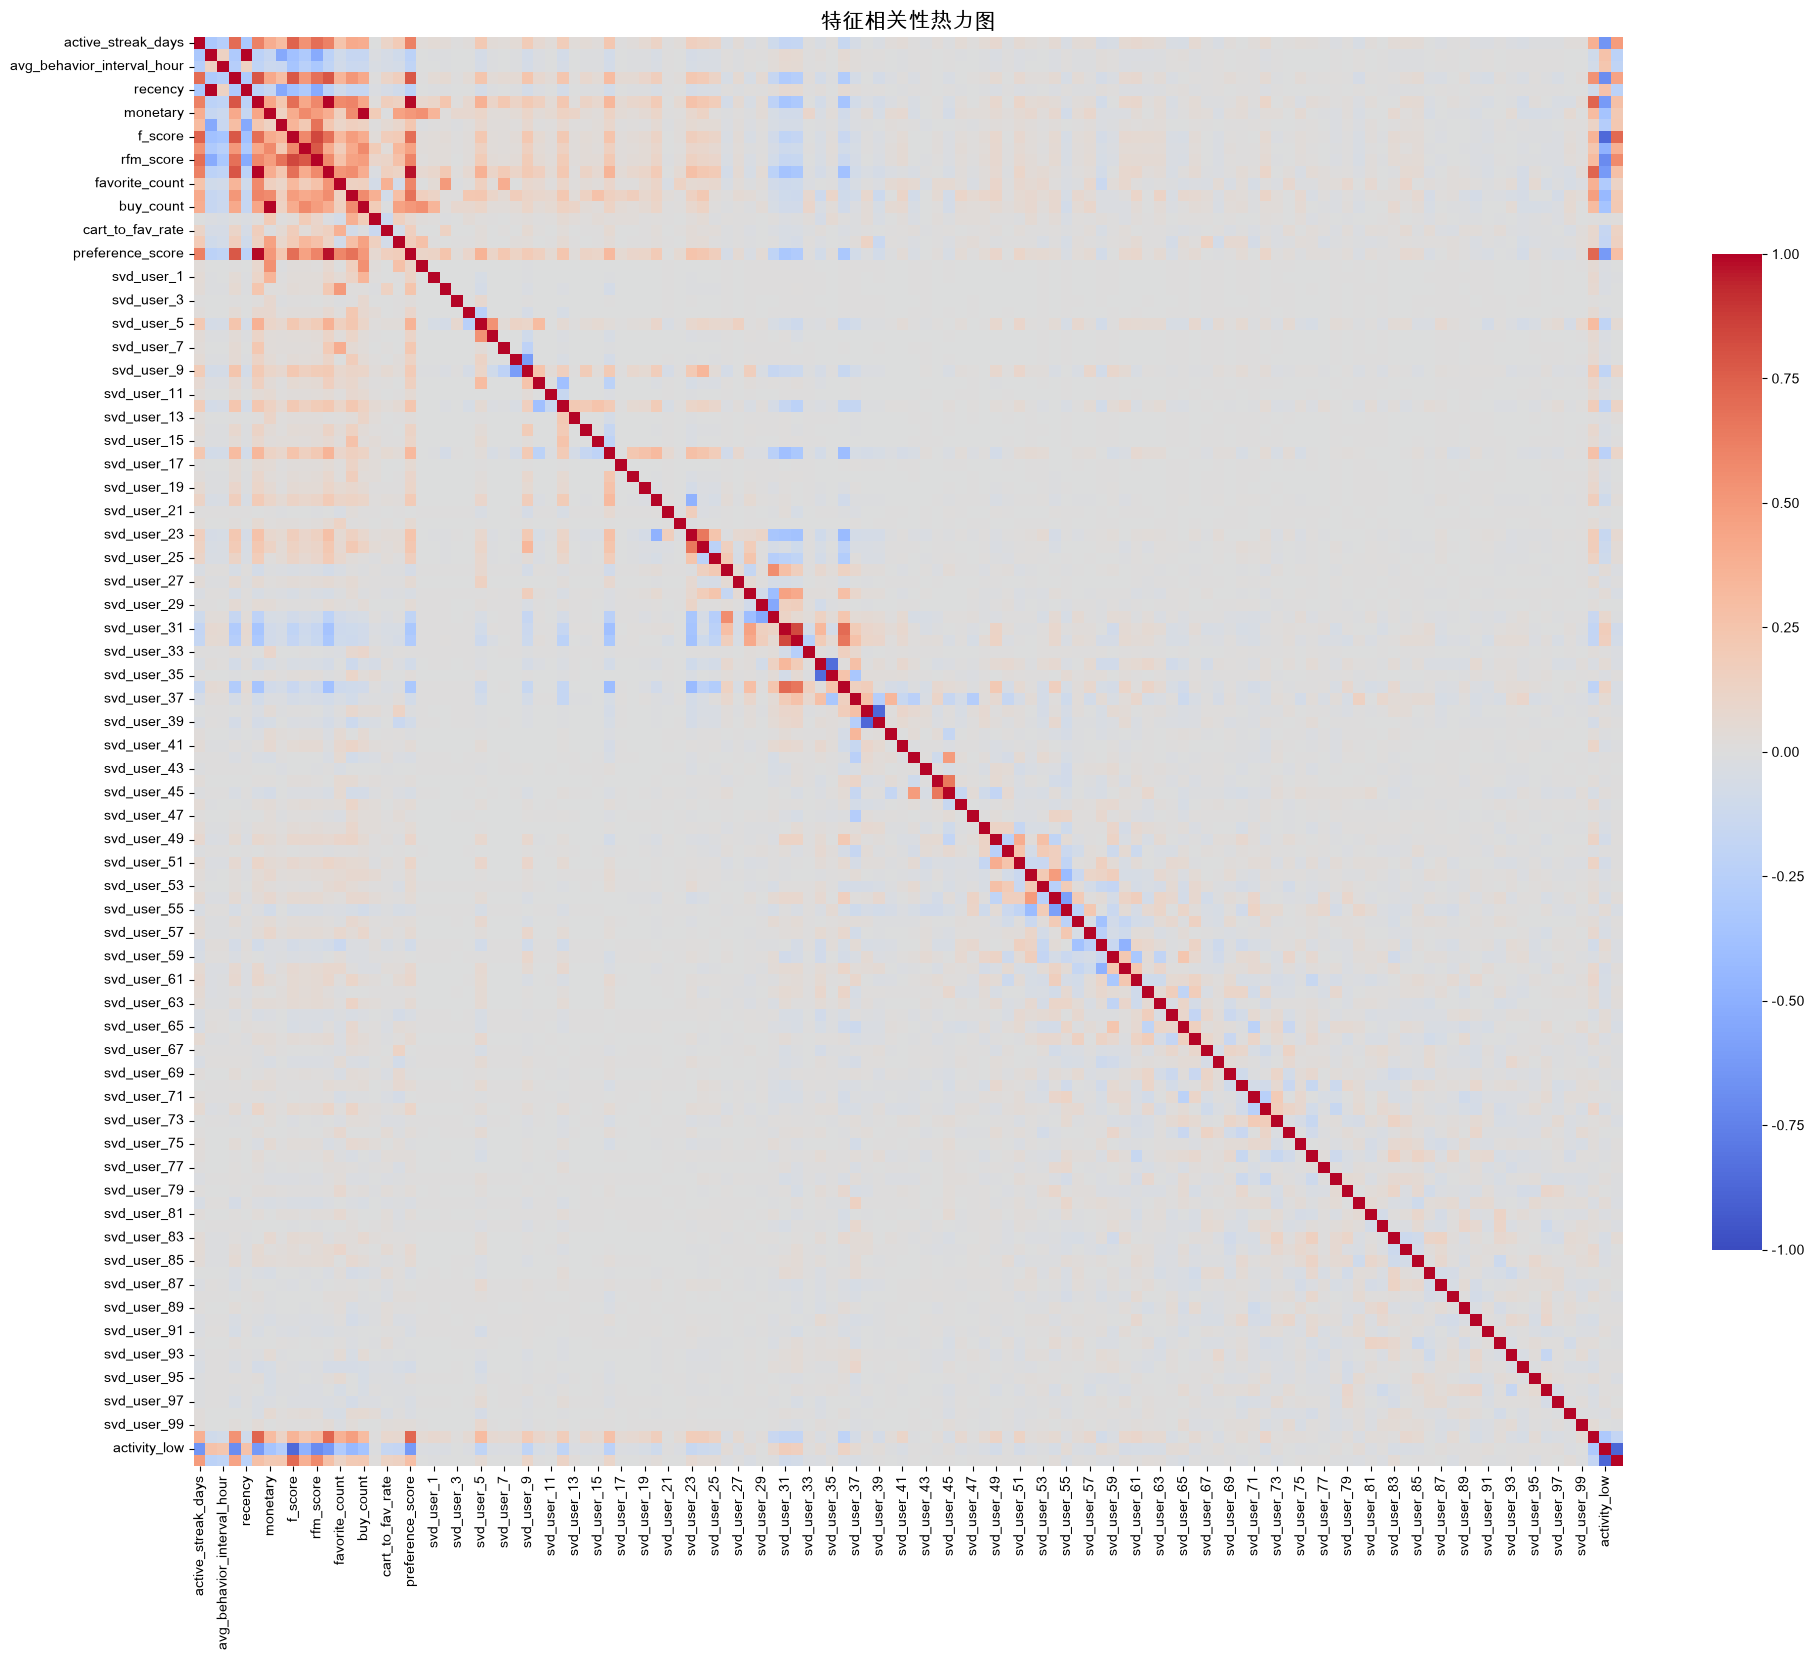

In [70]:
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
fig, ax = plt.subplots(figsize=(20, 18))

sns.heatmap(
    X_train_scaled.corr(),
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    cbar_kws={'shrink': 0.6},
    ax=ax
)
ax.set_title('特征相关性热力图', fontsize=16)
plt.tight_layout()
plt.show()

In [72]:
#检查高度相关特征：
threshold = 0.95
corr_matrix = X_train_scaled.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = [(col, row, upper.loc[row, col]) 
                   for col in upper.columns 
                   for row in upper.index 
                   if upper.loc[row, col] > threshold]

print(f"全局相关系数 > {threshold} 的特征对数量: {len(high_corr_pairs)}")
print("\n高度相关的特征对:")
for pair in high_corr_pairs:
    print(f"  {pair[0]} <-> {pair[1]}: {pair[2]:.4f}")

全局相关系数 > 0.95 的特征对数量: 5

高度相关的特征对:
  recency <-> churn_interval: 1.0000
  view_count <-> frequency: 0.9950
  buy_count <-> monetary: 1.0000
  preference_score <-> frequency: 0.9915
  preference_score <-> view_count: 0.9751


In [71]:
#SVD 100维内部的相关性
svd_cols = [c for c in X_train_scaled.columns if 'svd_user' in c]
svd_corr = X_train_scaled[svd_cols].corr().abs()

upper_svd = svd_corr.where(np.triu(np.ones(svd_corr.shape), k=1).astype(bool))

#高相关的SVD对
high_svd = [(col, row, upper_svd.loc[row, col]) 
            for col in upper_svd.columns 
            for row in upper_svd.index 
            if upper_svd.loc[row, col] > 0.95]

print(f"SVD内部相关系数>0.95的对数: {len(high_svd)}")
if high_svd:
    print("\n高度相关的SVD对（前10个）:")
    for pair in high_svd[:10]:
        print(f"  {pair[0]} <-> {pair[1]}: {pair[2]:.4f}")
else:
    print("SVD内部无高度相关特征")

SVD内部相关系数>0.95的对数: 0
SVD内部无高度相关特征


In [73]:
#删除高相关特征
drop_cols = ['churn_interval', 'view_count', 'buy_count', 'preference_score']

X_train_scaled = X_train_scaled.drop(columns=drop_cols)
X_val_scaled = X_val_scaled.drop(columns=drop_cols)
X_test_scaled = X_test_scaled.drop(columns=drop_cols)

print(f"\n删除后各集合形状:")
print(f"训练集: {X_train_scaled.shape}")
print(f"验证集: {X_val_scaled.shape}")
print(f"测试集: {X_test_scaled.shape}")


删除后各集合形状:
训练集: (6932, 118)
验证集: (1981, 118)
测试集: (991, 118)


In [ ]:
通过相关性分析检查特征之间相关性，删除相关性>0.95的高相关性特征：
删除churn_interval、view_count、preference_score：保留recency即可
删除buy_count：与研究定义的monetary（购买次数）定义相同

In [74]:
from sklearn.feature_selection import mutual_info_classif
#特征与标签的互信息
mi_scores = mutual_info_classif(X_train_scaled, y_train, random_state=42)

mi_df = pd.DataFrame({
    '特征': X_train_scaled.columns,
    '互信息': mi_scores
}).sort_values('互信息', ascending=False)

print("互信息最高的15个特征:")
print(mi_df.head(15).to_string(index=False))

print("\n互信息最低的15个特征:")
print(mi_df.tail(15).to_string(index=False))
print(f"互信息 < 0.01 的特征数: {(mi_df['互信息'] < 0.01).sum()}")

互信息最高的15个特征:
                特征      互信息
          monetary 0.082071
         rfm_score 0.079382
           m_score 0.071677
       svd_user_27 0.060821
       svd_user_25 0.052905
       svd_user_92 0.051648
       svd_user_19 0.051385
       svd_user_15 0.051153
        cart_count 0.048764
       svd_user_23 0.048698
active_streak_days 0.048618
    category_count 0.048286
        svd_user_2 0.047739
       svd_user_13 0.047693
       svd_user_24 0.047166

互信息最低的15个特征:
              特征      互信息
     svd_user_76 0.029142
     svd_user_33 0.028932
     svd_user_93 0.028389
     svd_user_63 0.028207
cart_to_fav_rate 0.027869
     svd_user_39 0.026534
     svd_user_40 0.026521
     svd_user_51 0.025697
     svd_user_66 0.025693
     svd_user_88 0.025323
     svd_user_77 0.025011
     svd_user_53 0.023089
    activity_low 0.022085
   activity_high 0.016968
  favorite_count 0.015040

互信息统计:
count    118.000000
mean       0.038692
std        0.009914
min        0.015040
25%        0.033549
5

In [ ]:
互信息法查看特征与目标变量的相关性。
monetary（购买次数）互信息最高，说明购买历史最直接预测未来购买。其次是rfm_score，说明RFM综合分有效。
SVD 多个维度排前列（svd_user_27、25、92...）——说明 SVD 隐向量确实有预测价值。
favorite_count 最低，说明收藏次数对未来购买预测力最弱。
数据内没有互信息 < 0.01 的特征，不用删除。

In [77]:
import os
save_dir = '/Users/neos/Desktop/Taobao DA/data_ready_for_modeling'
os.makedirs(save_dir, exist_ok=True)

X_train_scaled.to_parquet(f'{save_dir}/X_train.parquet', index=False)
X_val_scaled.to_parquet(f'{save_dir}/X_val.parquet', index=False)
X_test_scaled.to_parquet(f'{save_dir}/X_test.parquet', index=False)

y_train.to_frame('is_buy').to_parquet(f'{save_dir}/y_train.parquet', index=False)
y_val.to_frame('is_buy').to_parquet(f'{save_dir}/y_val.parquet', index=False)
y_test.to_frame('is_buy').to_parquet(f'{save_dir}/y_test.parquet', index=False)

id_train.to_frame('user_id').to_parquet(f'{save_dir}/id_train.parquet', index=False)
id_val.to_frame('user_id').to_parquet(f'{save_dir}/id_val.parquet', index=False)
id_test.to_frame('user_id').to_parquet(f'{save_dir}/id_test.parquet', index=False)

print(f"保存目录: {save_dir}")
print("\n文件列表:")
for f in sorted(os.listdir(save_dir)):
    size = os.path.getsize(os.path.join(save_dir, f)) / 1024**2
    print(f"  {f}: {size:.2f} MB")

保存目录: /Users/neos/Desktop/Taobao DA/data_ready_for_modeling

文件列表:
  X_test.parquet: 0.98 MB
  X_train.parquet: 6.64 MB
  X_val.parquet: 1.90 MB
  id_test.parquet: 0.01 MB
  id_train.parquet: 0.05 MB
  id_val.parquet: 0.01 MB
  y_test.parquet: 0.00 MB
  y_train.parquet: 0.00 MB
  y_val.parquet: 0.00 MB
